# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [1]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [2]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [3]:
# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


# Time Warping is necessary, or there would be falsely detected functional connection

## Creating ground truth with LIF neurons

In [241]:
from numpy import matlib
def toy_model_fr(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line-features["bump_center"])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def toy_model_fr_warping(features, time_line):
    log_fr_baseline = np.log(features["baseline"])
    log_fr_stimulus = features["bump_amp"] *np.exp(-((time_line[:, np.newaxis]- \
                                                      features["bump_center"][np.newaxis, :])/features["bump_wid"])**2)
    log_fr = log_fr_baseline + log_fr_stimulus
    features["log_fr"] = log_fr
    features["fr"] = np.exp(log_fr)

def generate_spike_train(fr, rep=1):
    if fr.ndim == 1:
        return np.random.poisson(lam=np.matlib.repmat(fr[:,np.newaxis],1,rep), size=None)
    else:
        return np.random.poisson(lam=np.matlib.repmat(fr,1,rep), size=None)

In [570]:
source = {"baseline": 0.01, "bump_center": np.nan, "bump_amp": 2, "bump_wid": 20}
target = {"baseline": 0.01, "bump_center": np.nan, "bump_amp": 2, "bump_wid": 20}
bump_center_mean = [240, 260]
bump_center_cov = np.array([[2500, 2250], [2250, 2500]])

nneuron = 1
nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
ntrial = 1000 # 5000 trials in total

spike_trains_source = []
spike_trains_target = []
time_line = np.arange(nt)
bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
source["bump_center"] = bump_centers[:, 0]
target["bump_center"] = bump_centers[:, 1]

for ineuron in range(nneuron):
    toy_model_fr_warping(source, time_line)
    spike_trains_source.append( generate_spike_train(source["fr"]) )
    toy_model_fr_warping(target, time_line)
    spike_trains_target.append( generate_spike_train(target["fr"]) )

Text(0.5, 1.0, 'ground truth firing rate')

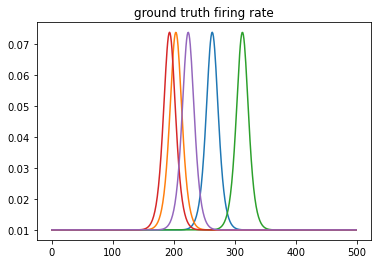

In [571]:
plt.plot(time_line, target["fr"][:, :5])
plt.title('ground truth firing rate')

## Single neuron level model without conditioning on peak timing

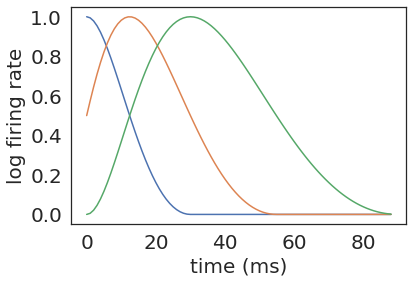

In [360]:
_ = GLM.make_pillow_basis(num=3, peaks_max=30, nonlinear=1, verbose=True)

In [506]:
from scipy.stats.distributions import chi2
from sklearn.model_selection import KFold

def likelihood_ratio_test(nll_diff, df_diff):
    return chi2.sf(2*nll_diff, df_diff)


In [512]:
for i, (train_index, test_index) in enumerate(kf.split(np.ones(10))):
    print(f"Fold {i}:")
    print(f"  Train: index={train_index}")
    print(f"  Test:  index={test_index}")

Fold 0:
  Train: index=[2 3 4 5 6 7 8 9]
  Test:  index=[0 1]
Fold 1:
  Train: index=[0 1 4 5 6 7 8 9]
  Test:  index=[2 3]
Fold 2:
  Train: index=[0 1 2 3 6 7 8 9]
  Test:  index=[4 5]
Fold 3:
  Train: index=[0 1 2 3 4 5 8 9]
  Test:  index=[6 7]
Fold 4:
  Train: index=[0 1 2 3 4 5 6 7]
  Test:  index=[8 9]


In [523]:
ntimes = 10
nfold = 10

from scipy.stats import ranksums

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0
    
    source = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 2, "bump_wid": 20}
    target = {"baseline": 0.05, "bump_center": np.nan, "bump_amp": 2, "bump_wid": 20}
    bump_center_mean = [240, 260]
    bump_center_cov = np.array([[2500, 2250], [2250, 2500]])

    nneuron = 10
    nt = 500 # Say there are 500 time bins each trial. Each time bin = 1ms. So each trial lasts for 1000ms
    ntrial = 250 # 5000 trials in total

    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    bump_centers = np.random.multivariate_normal(bump_center_mean, bump_center_cov, size=ntrial)
    source["bump_center"] = bump_centers[:, 0]
    target["bump_center"] = bump_centers[:, 1]

    for ineuron in range(nneuron):
        toy_model_fr_warping(source, time_line)
        spike_trains_source.append( generate_spike_train(source["fr"]) )
        toy_model_fr_warping(target, time_line)
        spike_trains_target.append( generate_spike_train(target["fr"]) )
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=20)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=30, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=20)
            model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=20)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=30, nonlinear=1)
        model_full_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                             method='mine', penalty=1e-2, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=20)
        model_nest_pop.fit_time_warping_baseline(target=output_spike_train_pool, max_iter=5, warp_interval=[[0, 0.5]], 
                                             method='mine', penalty=1e-2, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( ranksums( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

# result = ranksums( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|█████████████████████████████████| 10/10 [1:00:55<00:00, 365.58s/it]


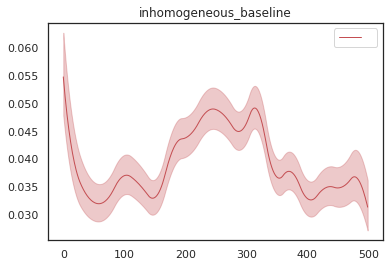

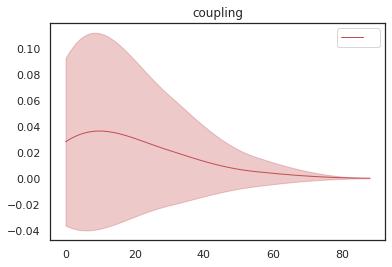

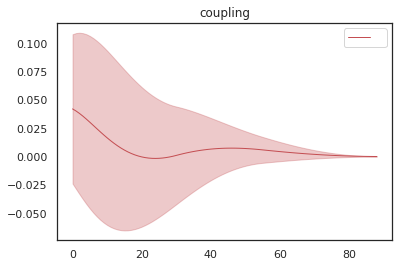

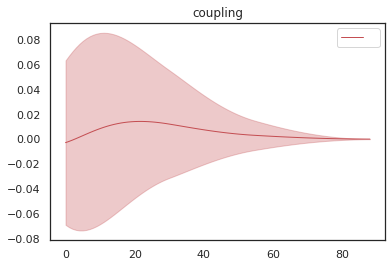

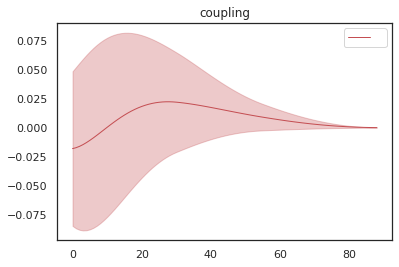

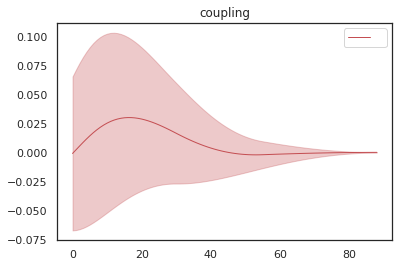

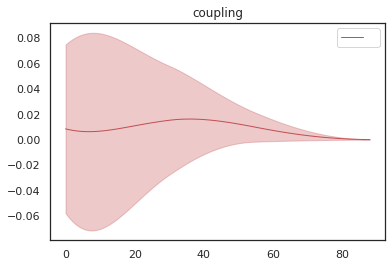

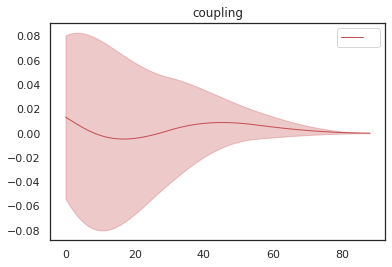

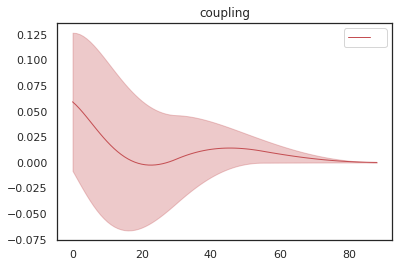

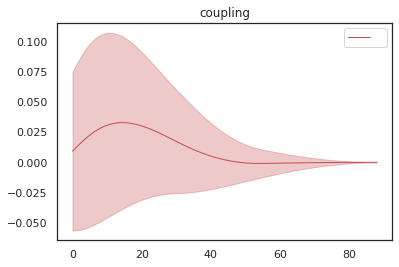

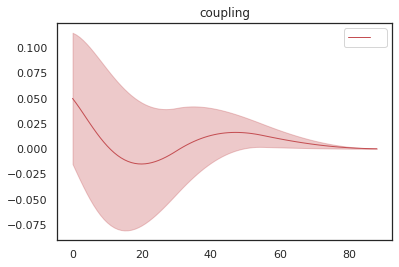

In [524]:
GLM.plot_GLM_compare(model_full)

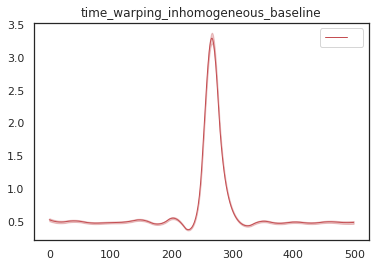

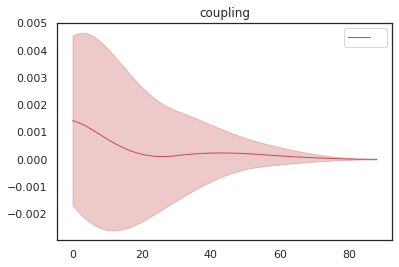

In [525]:
GLM.plot_GLM_compare(model_full_pop)

In [526]:
result

[RanksumsResult(statistic=-3.3987539419924113, pvalue=0.0003384679389090446),
 RanksumsResult(statistic=-3.9460730527086585, pvalue=3.972169223891612e-05),
 RanksumsResult(statistic=-3.716394497318805, pvalue=0.00010104298439993117),
 RanksumsResult(statistic=-3.064009664456135, pvalue=0.0010919592742725422),
 RanksumsResult(statistic=-3.491602719703203, pvalue=0.00024006590409305368),
 RanksumsResult(statistic=-3.41830105308942, pvalue=0.0003150668294221366),
 RanksumsResult(statistic=-3.5649043863169863, pvalue=0.00018199442746864224),
 RanksumsResult(statistic=-3.2448204421034665, pvalue=0.0005876235219043405),
 RanksumsResult(statistic=-3.7066209417703004, pvalue=0.0001050214775448034),
 RanksumsResult(statistic=-3.6137721640595086, pvalue=0.00015088713262330028)]

In [527]:
result_pop

[RanksumsResult(statistic=-0.4535573676110727, pvalue=0.32507372204742724),
 RanksumsResult(statistic=-0.6047431568147635, pvalue=0.2726748340055618),
 RanksumsResult(statistic=-0.5291502622129182, pvalue=0.29835060836467814),
 RanksumsResult(statistic=-0.30237157840738177, pvalue=0.3811844092349199),
 RanksumsResult(statistic=-0.9071147352221454, pvalue=0.18217306331677646),
 RanksumsResult(statistic=-0.9071147352221454, pvalue=0.18217306331677646),
 RanksumsResult(statistic=-0.30237157840738177, pvalue=0.3811844092349199),
 RanksumsResult(statistic=-0.680336051416609, pvalue=0.24814585111554643),
 RanksumsResult(statistic=-1.209486313629527, pvalue=0.11323803302174312),
 RanksumsResult(statistic=-0.4535573676110727, pvalue=0.32507372204742724)]

## Plot figures

In [ ]:
plt.subplots(figsize=(4, 6.9))

color_list = ['b', 'k', 'r']
plt.subplot(2,3,1)
for itrial in range(2,5):
    plt.plot(time_line, 1e3*source["fr"][:, itrial], color=color_list[itrial-2])
plt.title("Source neuron")
plt.xlabel("Time (ms)")
# plt.ylabel("Firing rate (spikes/sec)")

plt.subplot(2,3,4)
for itrial in range(2,5):
    plt.plot(time_line, 1e3*target["fr"][:, itrial], color=color_list[itrial-2])
plt.title("Target neuron")
plt.xlabel("Time (ms)")
# plt.ylabel("Firing rate (spikes/sec)")

plt.subplot(1,3,2)
plt.plot(bump_centers, ".")
plt.axline(xy1=(0, 0), slope=1)

plt.subplot(1,3,3)
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')
yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')
plt.axhline(0.05, ls='--', color='k', lw=1, label="P=0.05")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")

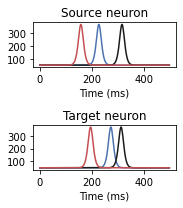

In [561]:
fontsize = 8
tickfontsize = 7
linewidth = 2
sns.reset_orig()
# sns.set_style('white')
plt.subplots(figsize=(6.9,3))

color_list = ['b', 'k', 'r']
plt.subplot(2, 3, 1)
for itrial in range(2,5):
    plt.plot(time_line, 1e3*source["fr"][:, itrial], color=color_list[itrial-2])
plt.title("Source neuron")
plt.xlabel("Time (ms)")
# plt.ylabel("Firing rate (spikes/sec)")

plt.subplot(2, 3, 4)
for itrial in range(2,5):
    plt.plot(time_line, 1e3*target["fr"][:, itrial], color=color_list[itrial-2])
plt.title("Target neuron")
plt.xlabel("Time (ms)")
# plt.ylabel("Firing rate (spikes/sec)")
plt.tight_layout()

# Sensitivity

In [594]:
ntimes = 10
nfold = 10

source = {"baseline": 0.01, "bump_center": 240, "bump_amp": 2, "bump_wid": 20}
target = {"baseline": 0.01, "bump_center": 260, "bump_amp": 2, "bump_wid": 20}

nneuron = 10
nt = 500
ntrial = 100
coupling_decay = 5
coupling_length = 30
coupling_strength = 0.03

from scipy.stats import ranksums

result = []
result_pop = []

for itimes in tqdm(range(ntimes)):
    test_nll_full = []
    test_nll_nest = []
    test_nll_full_pop = []
    test_nll_nest_pop = []
    nll_diff = 0
    nll_diff_pop = 0

    spike_trains_source = []
    spike_trains_target = []
    time_line = np.arange(nt)
    toy_model_fr(source, time_line)
    toy_model_fr(target, time_line)

    time_line_coupling = np.arange(coupling_length)
    ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)
    
    for ineuron in range(nneuron):
        spike_trains_source.append( generate_spike_train(source["fr"], rep=ntrial) )
    input_spike_train_pool = np.zeros((nt, ntrial))
    for input_spike_train in spike_trains_source:
        input_spike_train_pool += input_spike_train
    
    log_lambda_coupling = GLM.conv(input_spike_train_pool, ground_truth_coupling_filter[:, np.newaxis])
    log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
    target["fr"] = log_lambda_coupling + target["fr"][:, np.newaxis]
    for ineuron in range(nneuron):
        spike_trains_target.append( generate_spike_train(target["fr"]) )
    
    kf = KFold(n_splits=nfold)
    for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):
        
        training_trials = np.array( [False]*ntrial )
        training_trials[train_index] = True
        test_trials = np.logical_not(training_trials)

        ### Single neuron level model
        for output_spike_train in spike_trains_target:

            model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full.add_effect("inhomogeneous_baseline", num=20)
            for input_spike_train in spike_trains_source:
                model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=30, nonlinear=1)
            model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
            test_nll_full.append( model_full.test(test_trials) )

            model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest.add_effect("inhomogeneous_baseline", num=20)
            model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
            test_nll_nest.append( model_nest.test(test_trials) )
            nll_diff += model_nest.nll - model_full.nll

        ### Population level model
        output_spike_train_pool = np.zeros((nt, ntrial))
        for output_spike_train in spike_trains_target:
            output_spike_train_pool += output_spike_train
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_full_pop.add_effect("inhomogeneous_baseline", num=20)
        model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=30, nonlinear=1)
        model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
        test_nll_full_pop.append( model_full_pop.test(test_trials) )

        model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
        model_nest_pop.add_effect("inhomogeneous_baseline", num=20)
        model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
        test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
        nll_diff_pop += model_nest_pop.nll - model_full_pop.nll
    
    result.append( ranksums( test_nll_full, test_nll_nest, alternative='less') )
    result_pop.append( ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less') )

# result = ranksums( test_nll_full, test_nll_nest, alternative='less'),\
#             likelihood_ratio_test(nll_diff, ntimes*nneuron*3)
# result_pop = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less'),\
#                 likelihood_ratio_test(nll_diff_pop, ntimes*3)

100%|████████████████████████████████████| 10/10 [04:57<00:00, 29.77s/it]


In [595]:
result

[RanksumsResult(statistic=-1.6028631099547246, pvalue=0.05448243988635769),
 RanksumsResult(statistic=-1.568655665534959, pvalue=0.05836409711524249),
 RanksumsResult(statistic=-1.5857593877448417, pvalue=0.056396950802226516),
 RanksumsResult(statistic=-1.9082867208454874, pvalue=0.028177084178778476),
 RanksumsResult(statistic=-1.6492874988101205, pvalue=0.04954437475507281),
 RanksumsResult(statistic=-1.661504443245751, pvalue=0.048306088643448444),
 RanksumsResult(statistic=-1.6077498877289766, pvalue=0.05394498384037393),
 RanksumsResult(statistic=-1.6077498877289766, pvalue=0.05394498384037393),
 RanksumsResult(statistic=-1.7934474431505607, pvalue=0.03645070363216083),
 RanksumsResult(statistic=-1.6590610543586248, pvalue=0.0485517450267432)]

In [596]:
result_pop

[RanksumsResult(statistic=-3.4016802570830453, pvalue=0.00033486472451091354),
 RanksumsResult(statistic=-3.3260873624811995, pvalue=0.0004403715953708635),
 RanksumsResult(statistic=-3.4016802570830453, pvalue=0.00033486472451091354),
 RanksumsResult(statistic=-3.552866046286736, pvalue=0.00019052922602534275),
 RanksumsResult(statistic=-3.1749015732775088, pvalue=0.000749436668575838),
 RanksumsResult(statistic=-2.7969371002682815, pvalue=0.0025794787853606546),
 RanksumsResult(statistic=-3.779644730092272, pvalue=7.852614211537559e-05),
 RanksumsResult(statistic=-3.0993086786756634, pvalue=0.0009698640564515204),
 RanksumsResult(statistic=-3.6284589408885815, pvalue=0.00014255904181580633),
 RanksumsResult(statistic=-3.779644730092272, pvalue=7.852614211537559e-05)]

## Different number of trials

In [603]:
ntrial_list = [50, 100, 200, 500, 1000, 2000, 5000]
ntimes = 10
nfold = 10

source = {"baseline": 0.01, "bump_center": 240, "bump_amp": 2, "bump_wid": 20}
target = {"baseline": 0.01, "bump_center": 260, "bump_amp": 2, "bump_wid": 20}

nneuron = 10
nt = 500
ntrial = 500
coupling_decay = 5
coupling_length = 30
coupling_strength = 0.01
    
from scipy.stats import ranksums
result_mat = np.zeros((len(ntrial_list), ntimes))
result_mat_pop = np.zeros((len(ntrial_list), ntimes))

for intrial, ntrial in enumerate(ntrial_list):

    for itimes in tqdm(range(ntimes)):
        test_nll_full = []
        test_nll_nest = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)
        toy_model_fr(source, time_line)
        toy_model_fr(target, time_line)

        time_line_coupling = np.arange(coupling_length)
        ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)

        for ineuron in range(nneuron):
            spike_trains_source.append( generate_spike_train(source["fr"], rep=ntrial) )
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        log_lambda_coupling = GLM.conv(input_spike_train_pool, ground_truth_coupling_filter[:, np.newaxis])
        log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
        target["fr"] = log_lambda_coupling + target["fr"][:, np.newaxis]
        for ineuron in range(nneuron):
            spike_trains_target.append( generate_spike_train(target["fr"]) )

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=20)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=30, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=20)
                model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=20)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=30, nonlinear=1)
            model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=20)
            model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll

        result_mat[intrial, itimes] = ranksums( test_nll_full, test_nll_nest, alternative='less')[1]
        result_mat_pop[intrial, itimes] = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less')[1]


100%|████████████████████████████████| 10/10 [5:25:45<00:00, 1954.52s/it]


In [648]:
ntrial_list = [50, 100, 200, 500, 1000, 2000, 5000]
ntimes = 10
nfold = 10

source = {"baseline": 0.01, "bump_center": 240, "bump_amp": 2, "bump_wid": 20}
target = {"baseline": 0.01, "bump_center": 260, "bump_amp": 2, "bump_wid": 20}

nneuron = 10
nt = 500
ntrial = 500
coupling_decay = 5
coupling_length = 30
coupling_strength = 0.01
    
from scipy.stats import ranksums


for intrial, ntrial in enumerate(ntrial_list):
    if ntrial != 1000:
        continue
        
    for itimes in tqdm(range(ntimes)):
        test_nll_full = []
        test_nll_nest = []
        test_nll_full_pop = []
        test_nll_nest_pop = []
        nll_diff = 0
        nll_diff_pop = 0

        spike_trains_source = []
        spike_trains_target = []
        time_line = np.arange(nt)
        toy_model_fr(source, time_line)
        toy_model_fr(target, time_line)

        time_line_coupling = np.arange(coupling_length)
        ground_truth_coupling_filter = coupling_strength*np.exp(-time_line_coupling/coupling_decay)

        for ineuron in range(nneuron):
            spike_trains_source.append( generate_spike_train(source["fr"], rep=ntrial) )
        input_spike_train_pool = np.zeros((nt, ntrial))
        for input_spike_train in spike_trains_source:
            input_spike_train_pool += input_spike_train

        log_lambda_coupling = GLM.conv(input_spike_train_pool, ground_truth_coupling_filter[:, np.newaxis])
        log_lambda_coupling = log_lambda_coupling.reshape((nt, ntrial), order='F')
        target["fr"] = log_lambda_coupling + target["fr"][:, np.newaxis]
        for ineuron in range(nneuron):
            spike_trains_target.append( generate_spike_train(target["fr"]) )

        kf = KFold(n_splits=nfold)
        for ifold, (train_index, test_index) in enumerate(kf.split(np.ones(ntrial))):

            training_trials = np.array( [False]*ntrial )
            training_trials[train_index] = True
            test_trials = np.logical_not(training_trials)

            ### Single neuron level model
            for output_spike_train in spike_trains_target:

                model_full = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_full.add_effect("inhomogeneous_baseline", num=20)
                for input_spike_train in spike_trains_source:
                    model_full.add_effect("coupling", raw_input=input_spike_train, num=3, peaks_max=30, nonlinear=1)
                model_full.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
                test_nll_full.append( model_full.test(test_trials) )

                model_nest = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
                model_nest.add_effect("inhomogeneous_baseline", num=20)
                model_nest.fit(target=output_spike_train, method='mine', penalty=1e-2, verbose=False)
                test_nll_nest.append( model_nest.test(test_trials) )
                nll_diff += model_nest.nll - model_full.nll

            ### Population level model
            output_spike_train_pool = np.zeros((nt, ntrial))
            for output_spike_train in spike_trains_target:
                output_spike_train_pool += output_spike_train
            input_spike_train_pool = np.zeros((nt, ntrial))
            for input_spike_train in spike_trains_source:
                input_spike_train_pool += input_spike_train

            model_full_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_full_pop.add_effect("inhomogeneous_baseline", num=20)
            model_full_pop.add_effect("coupling", raw_input=input_spike_train_pool, num=3, peaks_max=30, nonlinear=1)
            model_full_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
            test_nll_full_pop.append( model_full_pop.test(test_trials) )

            model_nest_pop = GLM.PP_GLM(ntrial=ntrial, nt=nt, select_trials=training_trials)
            model_nest_pop.add_effect("inhomogeneous_baseline", num=20)
            model_nest_pop.fit(target=output_spike_train_pool, method='mine', penalty=1e-2, verbose=False)
            test_nll_nest_pop.append( model_nest_pop.test(test_trials) )
            nll_diff_pop += model_nest_pop.nll - model_full_pop.nll

        result_mat[intrial, itimes] = ranksums( test_nll_full, test_nll_nest, alternative='less')[1]
        result_mat_pop[intrial, itimes] = ranksums( test_nll_full_pop, test_nll_nest_pop, alternative='less')[1]


100%|█████████████████████████████████| 10/10 [1:11:51<00:00, 431.18s/it]


In [ ]:


plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels



In [640]:
SMALL_SIZE = 5
MEDIUM_SIZE = 7
BIGGER_SIZE = 8

from matplotlib import rcParams
rcParams['lines.linewidth'] = 1
rcParams['axes.labelsize'] = MEDIUM_SIZE
rcParams['axes.titlesize'] = BIGGER_SIZE
rcParams['font.size'] = MEDIUM_SIZE
rcParams['xtick.major.size'] = SMALL_SIZE
rcParams['ytick.major.size'] = SMALL_SIZE
rcParams['figure.titlesize'] = MEDIUM_SIZE
rcParams['legend.fontsize'] = MEDIUM_SIZE


Text(0, 0.5, 'P value')

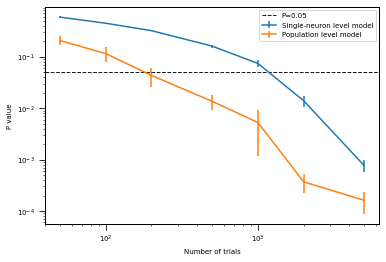

In [649]:
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')

yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')

plt.axhline(0.05, ls='--', color='k', lw=1, label="P=0.05")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")


Text(0, 0.5, 'P value')

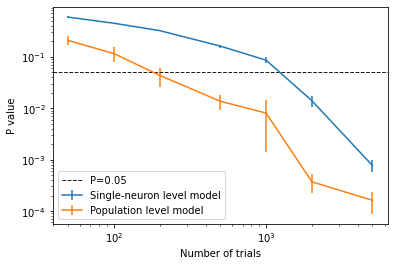

In [622]:
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')

yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')

plt.axhline(0.05, ls='--', color='k', lw=1, label="P=0.05")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")


In [ ]:
plt.subplots(figsize=(6.9, 3))

plt.subplot(2,3,1)
plt.plot(source["fr"])
plt.subplot(2,3,4)
plt.plot(target["fr"])

plt.subplot(1,3,2)
plt.plot(ground_truth_coupling_filter)

plt.subplot(1,3,3)
xx = ntrial_list
yy = (result_mat.mean(axis=1))
yerr = 2*(result_mat.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Single-neuron level model')
yy = (result_mat_pop.mean(axis=1))
yerr = 2*(result_mat_pop.std(axis=1))/np.sqrt(ntimes)
plt.errorbar(xx, yy, yerr=yerr, label='Population level model')
plt.axhline(0.05, ls='--', color='k', lw=1, label="P=0.05")
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel("Number of trials")
plt.ylabel("P value")


Text(0.5, 1.0, 'ground truth $\\gamma_{2,1,:}$')

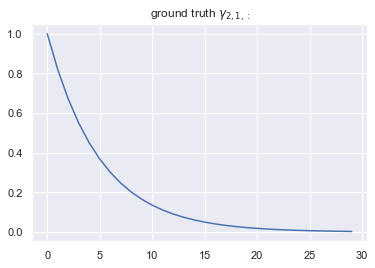

In [5]:
coupling_length = 30
time_line_coupling = np.arange(coupling_length)
ground_truth_coupling_filter = np.exp(-time_line_coupling/5)
plt.plot(ground_truth_coupling_filter)
plt.title('ground truth $\gamma_{2,1,:}$')

In [6]:

log_lambda_neuron2 = log_lambda_baseline + 0.5*log_lambda_stimulus[:,np.newaxis] + log_lambda_coupling
lambda_neuron2 = np.exp(log_lambda_neuron2)

If we look at the log lambda of a given trial, we can see the firing rate of neuron 2 suddenly jump up when neuron 1 spikes. 

Text(0.5, 1.0, 'log firing rate of an example trial')

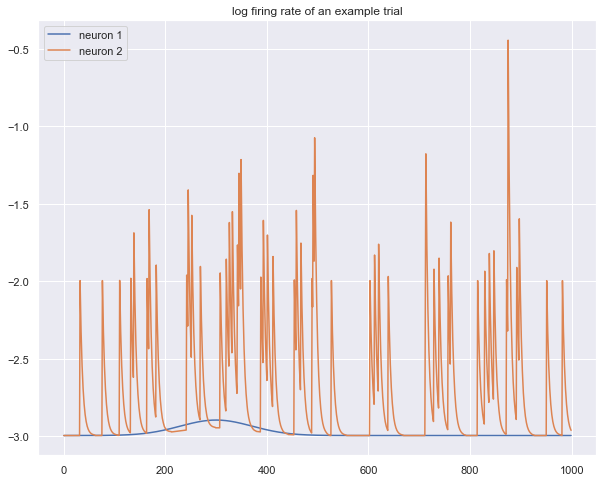

In [10]:
plt.subplots(figsize=(10,8))
plt.plot(log_lambda_neuron1, label='neuron 1')
plt.plot(log_lambda_neuron2[:,0], label='neuron 2')
plt.legend()
plt.title('log firing rate of an example trial')